In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

In [ ]:
df = pd.read_csv('/content/last_satis.csv')
pd.set_option('display.max_columns', None) #Print all columns

In [ ]:
df.head(5)

,Unnamed: 0,Tarix,Mağaza,Kart_nomresi,Transaksiya_id,Məhsul_nomresi,Məhsul_adi,Məhsul sayi,Ümumi satış
0,0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [ ]:
#Delete Irrelvatn and ID column

df.drop(columns=['Unnamed: 0'], inplace=True)
df.drop(columns=['Tarix'], inplace=True)
df.drop(columns=['Kart_nomresi'], inplace=True)
df.drop(columns=['Transaksiya_id'], inplace=True)

In [ ]:
df.head(10)

,Mağaza,Məhsul_nomresi,Məhsul_adi,Məhsul sayi,Ümumi satış
0,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,1,66,CCs Nacho Cheese 175g,3,6.3
2,1,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
5,4,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
6,4,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
7,4,24,Grain Waves Sweet Chilli 210g,1,3.6
8,5,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9
9,7,52,Grain Waves Sour Cream&Chives 210G,2,7.2


In [ ]:

df.drop(columns=['Mağaza'], inplace=True)
df.drop(columns=['Məhsul_nomresi'], inplace=True)

In [ ]:
df.head(5)

,Məhsul_adi,Məhsul sayi,Ümumi satış
0,Natural Chip Compny SeaSalt175g,2,6.0
1,CCs Nacho Cheese 175g,3,6.3
2,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [ ]:

df['Weight'] = df['Məhsul_adi'].str.extract(r'(\d+\s*g|\d+g)', expand=False)

df['Məhsul_adi'] = df['Məhsul_adi'].str.replace(r'(\d+\s*g|\d+g)', '', regex=True).str.strip()

df.head(5)

,Məhsul_adi,Məhsul sayi,Ümumi satış,Weight
0,Natural Chip Compny SeaSalt,2,6.0,175g
1,CCs Nacho Cheese,3,6.3,175g
2,Smiths Crinkle Cut Chips Chicken,2,2.9,170g
3,Smiths Chip Thinly S/Cream&Onion,5,15.0,175g
4,Kettle Tortilla ChpsHny&Jlpno Chili,3,13.8,150g


In [ ]:
df['Weight'] = df['Weight'].replace('g', '', regex=True)


In [ ]:
df.head(5)

,Məhsul_adi,Məhsul sayi,Ümumi satış,Weight
0,Natural Chip Compny SeaSalt,2,6.0,175
1,CCs Nacho Cheese,3,6.3,175
2,Smiths Crinkle Cut Chips Chicken,2,2.9,170
3,Smiths Chip Thinly S/Cream&Onion,5,15.0,175
4,Kettle Tortilla ChpsHny&Jlpno Chili,3,13.8,150


In [ ]:
df['Taste'] = df['Məhsul_adi'].str.extract(r'(\S+)$')

df['Məhsul_adi'] = df['Məhsul_adi'].str.replace(r'\s*\S+$', '', regex=True)
df.head(5)


,Məhsul_adi,Məhsul sayi,Ümumi satış,Weight,Taste
0,Natural Chip Compny,2,6.0,175,SeaSalt
1,CCs Nacho,3,6.3,175,Cheese
2,Smiths Crinkle Cut Chips,2,2.9,170,Chicken
3,Smiths Chip Thinly,5,15.0,175,S/Cream&Onion
4,Kettle Tortilla ChpsHny&Jlpno,3,13.8,150,Chili


In [ ]:
df['Brand'] = df['Məhsul_adi'].str.extract(r'^(\S+)', expand=False)
df.head(10)

,Məhsul_adi,Məhsul sayi,Ümumi satış,Weight,Taste,Brand
0,Natural Chip Compny,2,6.0,175,SeaSalt,Natural
1,CCs Nacho,3,6.3,175,Cheese,CCs
2,Smiths Crinkle Cut Chips,2,2.9,170,Chicken,Smiths
3,Smiths Chip Thinly,5,15.0,175,S/Cream&Onion,Smiths
4,Kettle Tortilla ChpsHny&Jlpno,3,13.8,150,Chili,Kettle
5,Old El Paso Salsa Dip Tomato,1,5.1,300,Mild,Old
6,Smiths Crinkle Chips Salt &,1,5.7,330,Vinegar,Smiths
7,Grain Waves Sweet,1,3.6,210,Chilli,Grain
8,Doritos Corn Chip Mexican,1,3.9,150,Jalapeno,Doritos
9,Grain Waves Sour Cream&Chives,2,7.2,NaN,210G,Grain


In [ ]:
pipeline.predict([2, 170, 3, 5])

NameError: name 'pipeline' is not defined

In [ ]:
df.drop(columns=['Məhsul_adi'], inplace=True)

In [ ]:
pip

In [ ]:
df.head(5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Məhsul_adi   200000 non-null  object 
 1   Məhsul sayi  200000 non-null  int64  
 2   Ümumi satış  200000 non-null  float64
 3   Weight       195416 non-null  object 
 4   Taste        200000 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 7.6+ MB


In [ ]:
df.isnull().sum()

,0
Məhsul_adi,0
Məhsul sayi,0
Ümumi satış,0
Weight,4584
Taste,0


In [ ]:
df.Weight.unique()

array(['175', '170', '150', '300', '330', '210', nan, '270', '220', '125',
       '110', '134', '380', '180', '165', '135', '250', '200', '160',
       '190', '90', '70'], dtype=object)

In [ ]:
#Check again IQR

# Select only numerical columns
numeric_df = df.select_dtypes(include='number')

# List to store column names with outliers
columns_with_outliers = []

# Check each column for outliers (with nunique > 2)
for col in numeric_df.columns:
    if col != 'Ümumi satış':  # Only consider columns with more than 2 unique values
        Q1 = numeric_df[col].quantile(0.25)
        Q3 = numeric_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Check if any outliers exist
        if ((numeric_df[col] < lower) | (numeric_df[col] > upper)).any():
            columns_with_outliers.append(col)

print("Columns with outliers:", columns_with_outliers)


Columns with outliers: ['Məhsul sayi']


In [ ]:
#Solve outliers problems with clip values methods

for col in columns_with_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Clip values outside bounds
    df[col] = np.clip(df[col], lower, upper)

In [ ]:
#Lets check again outliers from dataset

numeric_df = df.select_dtypes(include='number')

columns_with_outliers = []

for col in numeric_df.columns:
   if numeric_df[col].nunique() > 2 and col != 'Qiymet':
        Q1 = numeric_df[col].quantile(0.25)
        Q3 = numeric_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        if ((numeric_df[col] < lower) | (numeric_df[col] > upper)).any():
            columns_with_outliers.append(col)

print("Columns with outliers:", columns_with_outliers)

Columns with outliers: ['Ümumi satış']


In [ ]:
df = df.dropna()


In [ ]:
df.isnull().sum()

,0
Məhsul_adi,0
Məhsul sayi,0
Ümumi satış,0
Weight,0
Taste,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195416 entries, 0 to 199999
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Məhsul_adi   195416 non-null  object 
 1   Məhsul sayi  195416 non-null  int64  
 2   Ümumi satış  195416 non-null  float64
 3   Weight       195416 non-null  object 
 4   Taste        195416 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.9+ MB


In [ ]:
df['Weight'] = df['Weight'].astype('int')

<ipython-input-112-069dad4e8079>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Weight'] = df['Weight'].astype('int')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195416 entries, 0 to 199999
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Məhsul_adi   195416 non-null  object 
 1   Məhsul sayi  195416 non-null  int64  
 2   Ümumi satış  195416 non-null  float64
 3   Weight       195416 non-null  int64  
 4   Taste        195416 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 8.9+ MB


<Axes: >

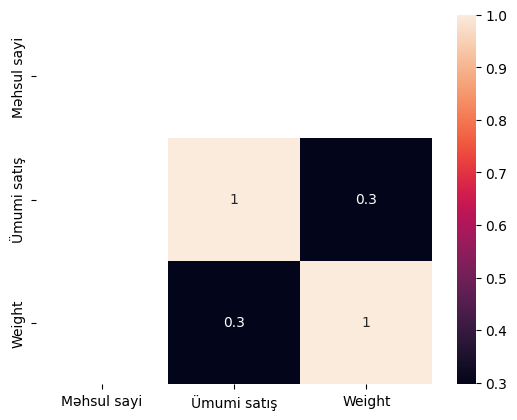

In [ ]:
import seaborn as sns
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)

In [ ]:


numeric_feature = make_column_selector(dtype_include='number')
categoric_feature = make_column_selector(dtype_include='object')


numeric_transform = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categoric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoding', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transform, numeric_feature),
        ('cat', categoric_transformer, categoric_feature)
    ]
)

model = RandomForestRegressor()

pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', model)])


In [ ]:
x = df.drop(columns=['Ümumi satış'])
y = df['Ümumi satış']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

pipeline.fit(x_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b83940c7610>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoding',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b8393f80f50>)])),
                ('model', RandomForestRegressor())])

In [ ]:
y_pred = pipeline.predict(x_test)


mean_error = mean_squared_error(y_test, y_pred)
r2_scored = r2_score(y_test, y_pred)

r2_scored


0.997144742524127

In [ ]:
from sklearn.linear_model import LinearRegression
model1 = LinearRegression()

pipeline1 = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', model)])

pipeline1.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)


mean_error = mean_squared_error(y_test, y_pred)
r2_scored = r2_score(y_test, y_pred)

r2_scored

0.9972740211197388

In [ ]:
from sklearn.linear_model import Ridge
model2 = Ridge()

pipeline2 = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', model)])


pipeline2.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)


mean_error = mean_squared_error(y_test, y_pred)
r2_scored = r2_score(y_test, y_pred)

r2_scored

0.9972674805453687

In [ ]:


model3 = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

pipeline3 = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', model)])


pipeline3.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)


mean_error = mean_squared_error(y_test, y_pred)
r2_scored = r2_score(y_test, y_pred)

r2_scored

0.9972280422974643

In [ ]:


voting_model = VotingRegressor([
    ('ridge', Ridge()),
    ('svr', SVR()),
    ('rf', RandomForestRegressor())
])

pipeline4 = Pipeline([('preprocessor', preprocessor), ('model', voting_model)])


In [ ]:
pipeline4.fit(x_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b83940c7610>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoding',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b8393f80f50>)])),
                ('model',
                 VotingRegressor(estimators=[('ridge', Ridge()), ('svr', SVR()),
                                             ('rf',
                                              RandomForestRegressor())]))])